# 🛒 ShopSphere E-Commerce Sales Analysis
### A Complete Data Analysis Project — Load → Clean → Analyze → Visualize

**Author:** _Your Name Here_
**Date:** _Update before submission_
**Tool:** Python (pandas, numpy, matplotlib) on Google Colab

---

## 📌 Project Overview

**Goal:** Analyze two years (Jan 2024 – Dec 2025) of order-level transaction data from
*ShopSphere*, a fictional online retailer, to understand:

1. Which product categories generate the most revenue
2. How sales trend month-over-month (and whether there is seasonality)
3. How revenue is distributed across regions
4. How customers prefer to pay, and how new vs. returning customers compare

**Why this matters:** these are the exact questions a real e-commerce business asks
before planning inventory, marketing spend, and regional expansion.

**Dataset:** `data/ecommerce_sales.csv` — 4,615 raw order records with realistic
"messy" data (missing values, inconsistent text casing, duplicate rows, and a few
invalid entries) so the cleaning step below does real work, just like with real-world data.

---

## ▶️ How to run this notebook in Google Colab

You have two options — **pick whichever is easiest for you**:

**Option A — Use the real project data (recommended)**
1. Upload the whole project folder to Google Drive (or just the `data/` folder).
2. In Colab: `Runtime > Run all` after mounting Drive (code provided below, just
   uncomment the two lines in the next cell and set the correct path).

**Option B — Just run it, no upload needed**
- If `data/ecommerce_sales.csv` isn't found, the notebook **automatically regenerates
  an identical dataset** (same random seed) in Section 1 below, so every cell works
  immediately with zero setup. This is the easiest way to try the notebook out.

Either way, every other cell below runs unchanged.

In [1]:
# ── Setup: install / import libraries ──
# (matplotlib, pandas, numpy come pre-installed on Google Colab — nothing to install)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

print("Libraries loaded:")
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
import matplotlib
print("matplotlib:", matplotlib.__version__)

Libraries loaded:
pandas  : 3.0.2
numpy   : 2.4.4
matplotlib: 3.10.8


## 📁 Optional: Mount Google Drive

Only needed if you uploaded the project folder to Drive (Option A above).
Uncomment and edit `PROJECT_PATH` to match where you placed the folder.

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# PROJECT_PATH = "/content/drive/MyDrive/ecommerce-sales-analysis"   # <- edit this path
# os.chdir(PROJECT_PATH)
# print("Working directory:", os.getcwd())

## 1️⃣ Load the Data

We first try to load the real project dataset from `data/ecommerce_sales.csv`.
If it isn't found (e.g. you're running this fresh in Colab with no upload), the
notebook regenerates an equivalent dataset using a fixed random seed so the rest
of the analysis runs identically either way.

In [3]:
DATA_PATH = "data/ecommerce_sales.csv"

def generate_fallback_dataset(path):
    """Recreates the project dataset if it isn't found on disk (Colab-friendly fallback)."""
    print("⚠️  data/ecommerce_sales.csv not found — generating an equivalent dataset instead...")
    np.random.seed(42)
    N_ORDERS = 4000
    categories = ["Electronics", "Clothing", "Home & Kitchen", "Books", "Beauty", "Sports"]
    price_range = {"Electronics": (1500, 45000), "Clothing": (300, 4500),
                    "Home & Kitchen": (400, 12000), "Books": (150, 1800),
                    "Beauty": (200, 3500), "Sports": (350, 9000)}
    regions = ["North", "South", "East", "West"]
    payments = ["Credit Card", "Debit Card", "UPI", "Net Banking", "Cash on Delivery"]
    segments = ["New", "Returning"]
    statuses = ["Delivered", "Returned", "Cancelled"]
    from datetime import datetime, timedelta
    start, end = datetime(2024, 1, 1), datetime(2025, 12, 31)
    span = (end - start).days

    rows = []
    for i in range(1, N_ORDERS + 1):
        cat = np.random.choice(categories, p=[0.22, 0.20, 0.18, 0.12, 0.16, 0.12])
        low, high = price_range[cat]
        price = round(np.random.uniform(low, high), 2)
        qty = int(np.random.choice([1, 1, 1, 2, 2, 3, 4], p=[0.35, 0.2, 0.15, 0.15, 0.07, 0.05, 0.03]))
        disc = np.random.choice([0, 5, 10, 15, 20, np.nan], p=[0.35, 0.2, 0.2, 0.12, 0.08, 0.05])
        region = np.random.choice(regions, p=[0.28, 0.27, 0.22, 0.23])
        pay = np.random.choice(payments + [np.nan], p=[0.28, 0.22, 0.27, 0.13, 0.07, 0.03])
        seg = np.random.choice(segments, p=[0.42, 0.58])
        date = start + timedelta(days=int(np.random.randint(0, span)))
        status = np.random.choice(statuses, p=[0.86, 0.09, 0.05])

        cat_disp = cat.lower() if np.random.rand() < 0.08 else (cat.upper() if np.random.rand() < 0.05 else cat)
        region_disp = region.lower() if np.random.rand() < 0.06 else region
        pay_disp = pay.lower() if isinstance(pay, str) and np.random.rand() < 0.05 else pay
        if np.random.rand() < 0.01: qty = 0
        if np.random.rand() < 0.005: price = -price

        rows.append({"Order ID": f"ORD{i:05d}", "Order Date": date.strftime("%Y-%m-%d"),
                     "Product Category": cat_disp, "Quantity": qty, "Unit Price (INR)": price,
                     "Discount (%)": disc, "Region": region_disp, "Payment Method": pay_disp,
                     "Customer Segment": seg, "Order Status": status})

    for j in range(600):
        base = rows[np.random.randint(0, len(rows))].copy()
        y, m, d = np.random.choice([2024, 2025]), np.random.choice([10, 11, 12]), np.random.randint(1, 28)
        base["Order ID"] = f"ORD{N_ORDERS + j + 1:05d}"
        base["Order Date"] = f"{y}-{m:02d}-{d:02d}"
        rows.append(base)

    out = pd.DataFrame(rows)
    out = pd.concat([out, out.sample(15, random_state=1)], ignore_index=True)
    out = out.sample(frac=1, random_state=7).reset_index(drop=True)
    os.makedirs(os.path.dirname(path) if os.path.dirname(path) else ".", exist_ok=True)
    out.to_csv(path, index=False)
    return out

if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
    print("✅ Loaded existing dataset from:", DATA_PATH)
else:
    df_raw = generate_fallback_dataset(DATA_PATH)
    print("✅ Generated fallback dataset and saved to:", DATA_PATH)

print("\nShape:", df_raw.shape)
df_raw.head(10)

✅ Loaded existing dataset from: data/ecommerce_sales.csv

Shape: (4615, 10)


,Order ID,Order Date,Product Category,Quantity,Unit Price (INR),Discount (%),Region,Payment Method,Customer Segment,Order Status
0,ORD01933,2024-10-29,Beauty,1,2886.34,5.0,East,Debit Card,Returning,Delivered
1,ORD03883,2024-11-30,home & kitchen,3,10288.77,NaN,South,UPI,Returning,Delivered
2,ORD01678,2025-02-11,sports,1,8723.64,10.0,North,Credit Card,Returning,Delivered
3,ORD01579,2025-10-30,Clothing,2,3055.23,15.0,East,Debit Card,New,Delivered
4,ORD03146,2024-06-17,Beauty,0,1534.70,10.0,North,Debit Card,Returning,Delivered
5,ORD01223,2024-10-10,Electronics,2,35492.84,15.0,West,Credit Card,New,Delivered
6,ORD03882,2025-05-30,Sports,1,8274.95,10.0,East,NaN,Returning,Delivered
7,ORD01441,2024-11-24,Books,4,310.24,0.0,east,Net Banking,Returning,Delivered
8,ORD02389,2025-10-25,Electronics,1,7689.95,15.0,West,Net Banking,Returning,Delivered
9,ORD02627,2024-04-11,Books,1,410.88,NaN,West,Debit Card,New,Delivered


## 2️⃣ Explore the Raw Data

Before cleaning anything, let's understand what we're working with: column types,
missing values, and obvious data-quality issues.

In [4]:
print("Column data types:\n")
print(df_raw.dtypes)

print("\nMissing values per column:\n")
print(df_raw.isna().sum())

print("\nExact duplicate rows:", df_raw.duplicated().sum())

print("\nUnique 'Product Category' raw values (notice inconsistent casing):")
print(sorted(df_raw["Product Category"].astype(str).unique()))

print("\nRows with invalid Quantity (<= 0):", (df_raw["Quantity"] <= 0).sum())
print("Rows with invalid Unit Price (< 0):", (df_raw["Unit Price (INR)"] < 0).sum())

Column data types:

Order ID                str
Order Date              str
Product Category        str
Quantity              int64
Unit Price (INR)    float64
Discount (%)        float64
Region                  str
Payment Method          str
Customer Segment        str
Order Status            str
dtype: object

Missing values per column:

Order ID              0
Order Date            0
Product Category      0
Quantity              0
Unit Price (INR)      0
Discount (%)        254
Region                0
Payment Method      117
Customer Segment      0
Order Status          0
dtype: int64

Exact duplicate rows: 15

Unique 'Product Category' raw values (notice inconsistent casing):
['BEAUTY', 'BOOKS', 'Beauty', 'Books', 'CLOTHING', 'Clothing', 'ELECTRONICS', 'Electronics', 'HOME & KITCHEN', 'Home & Kitchen', 'SPORTS', 'Sports', 'beauty', 'books', 'clothing', 'electronics', 'home & kitchen', 'sports']

Rows with invalid Quantity (<= 0): 46
Rows with invalid Unit Price (< 0): 21


## 3️⃣ Clean the Data

Issues found above and how we fix each one:

| Issue | Fix |
|---|---|
| Inconsistent text casing (`"electronics"`, `"ELECTRONICS"`, `"Electronics"`) | Standardize to title case |
| Missing `Discount (%)` | Fill with `0` (no discount applied) |
| Missing `Payment Method` | Fill with `"Unknown"` (a valid, trackable category) |
| Exact duplicate rows | Drop duplicates |
| Invalid `Quantity` (≤ 0) or `Unit Price` (negative) | Drop — these are data-entry errors, not real orders |
| `Order Date` stored as text | Convert to proper `datetime` |


In [5]:
df = df_raw.copy()

# Standardize text columns
text_cols = ["Product Category", "Region", "Payment Method", "Customer Segment", "Order Status"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col] = df[col].replace({"Nan": np.nan})
df["Payment Method"] = df["Payment Method"].replace({"Upi": "UPI"})

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Remove invalid numeric entries (data-entry errors)
before = len(df)
df = df[(df["Quantity"] > 0) & (df["Unit Price (INR)"] > 0)]
print(f"Removed {before - len(df)} rows with invalid quantity/price")

# Fill missing values with sensible defaults
df["Discount (%)"] = df["Discount (%)"].fillna(0)
df["Payment Method"] = df["Payment Method"].fillna("Unknown")

# Convert date column properly
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date"])

# Derive Revenue, Month, Year — the fields our analysis actually needs
df["Revenue (INR)"] = (df["Quantity"] * df["Unit Price (INR)"] * (1 - df["Discount (%)"] / 100)).round(2)
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Year"] = df["Order Date"].dt.year

print(f"\nFinal cleaned shape: {df.shape}  (started at {df_raw.shape})")
df.head()

Removed 15 duplicate rows
Removed 67 rows with invalid quantity/price

Final cleaned shape: (4533, 13)  (started at (4615, 10))


,Order ID,Order Date,Product Category,Quantity,Unit Price (INR),Discount (%),Region,Payment Method,Customer Segment,Order Status,Revenue (INR),Month,Year
0,ORD01933,2024-10-29,Beauty,1,2886.34,5.0,East,Debit Card,Returning,Delivered,2742.02,2024-10,2024
1,ORD03883,2024-11-30,Home & Kitchen,3,10288.77,0.0,South,UPI,Returning,Delivered,30866.31,2024-11,2024
2,ORD01678,2025-02-11,Sports,1,8723.64,10.0,North,Credit Card,Returning,Delivered,7851.28,2025-02,2025
3,ORD01579,2025-10-30,Clothing,2,3055.23,15.0,East,Debit Card,New,Delivered,5193.89,2025-10,2025
5,ORD01223,2024-10-10,Electronics,2,35492.84,15.0,West,Credit Card,New,Delivered,60337.83,2024-10,2024


## ✅ 4️⃣ Validate the Cleaning (Testing Evidence)

Before trusting any analysis built on top of `df`, we assert the data actually
meets the conditions we expect. If any assertion fails, the notebook stops here
rather than silently producing a wrong report.

In [6]:
# Test 1: no missing values remain in any column we rely on
required_cols = ["Order Date", "Product Category", "Quantity", "Unit Price (INR)",
                  "Discount (%)", "Region", "Payment Method", "Revenue (INR)"]
missing_after = df[required_cols].isna().sum()
assert missing_after.sum() == 0, f"Unexpected missing values remain:\n{missing_after}"
print("✅ Test 1 passed: no missing values in required columns")

# Test 2: no negative or zero quantities / prices
assert (df["Quantity"] > 0).all(), "Found non-positive quantity after cleaning!"
assert (df["Unit Price (INR)"] > 0).all(), "Found non-positive price after cleaning!"
print("✅ Test 2 passed: all quantities and prices are positive")

# Test 3: no duplicate rows remain
assert df.duplicated().sum() == 0, "Duplicate rows still present!"
print("✅ Test 3 passed: no duplicate rows")

# Test 4: category/region/payment text is standardized (title case, finite set)
assert set(df["Product Category"].unique()) <= {
    "Electronics", "Clothing", "Home & Kitchen", "Books", "Beauty", "Sports"
}, "Unexpected category values found — casing standardization failed!"
print("✅ Test 4 passed: category values are standardized")

# Test 5: Revenue was computed correctly for a random sample (spot-check formula)
sample = df.sample(5, random_state=0)
recomputed = (sample["Quantity"] * sample["Unit Price (INR)"] * (1 - sample["Discount (%)"] / 100)).round(2)
assert np.allclose(sample["Revenue (INR)"].values, recomputed.values), "Revenue formula mismatch!"
print("✅ Test 5 passed: Revenue formula verified on a random sample")

print("\n🎉 All validation checks passed — the cleaned dataset is ready for analysis.")

✅ Test 1 passed: no missing values in required columns
✅ Test 2 passed: all quantities and prices are positive
✅ Test 3 passed: no duplicate rows
✅ Test 4 passed: category values are standardized
✅ Test 5 passed: Revenue formula verified on a random sample

🎉 All validation checks passed — the cleaned dataset is ready for analysis.


## 5️⃣ Analyze: Key Metrics & Patterns

We compute the core KPIs a business stakeholder would ask for first, then break
revenue down by category, month, region, and payment method.

In [7]:
delivered = df[df["Order Status"] == "Delivered"]

total_revenue     = delivered["Revenue (INR)"].sum()
total_orders      = df["Order ID"].nunique()
delivered_orders  = len(delivered)
avg_order_value   = delivered["Revenue (INR)"].mean()
return_rate       = (df["Order Status"] == "Returned").mean() * 100
cancel_rate       = (df["Order Status"] == "Cancelled").mean() * 100

print("📊 KEY PERFORMANCE INDICATORS")
print("-" * 40)
print(f"Total Orders (all statuses) : {total_orders:,}")
print(f"Delivered Orders            : {delivered_orders:,}")
print(f"Total Revenue (delivered)   : ₹{total_revenue:,.2f}")
print(f"Average Order Value         : ₹{avg_order_value:,.2f}")
print(f"Return Rate                 : {return_rate:.2f}%")
print(f"Cancellation Rate           : {cancel_rate:.2f}%")

📊 KEY PERFORMANCE INDICATORS
----------------------------------------
Total Orders (all statuses) : 4,533
Delivered Orders            : 3,887
Total Revenue (delivered)   : ₹38,602,356.07
Average Order Value         : ₹9,931.14
Return Rate                 : 9.00%
Cancellation Rate           : 5.25%


In [8]:
revenue_by_category = delivered.groupby("Product Category")["Revenue (INR)"].sum().sort_values(ascending=False)
revenue_share_pct = (revenue_by_category / revenue_by_category.sum() * 100).round(1)

print("Revenue by Product Category:\n")
summary = pd.DataFrame({"Revenue (INR)": revenue_by_category, "Share (%)": revenue_share_pct})
summary

Revenue by Product Category:



,Revenue (INR),Share (%)
Product Category,,
Electronics,25333033.52,65.6
Home & Kitchen,5599917.34,14.5
Sports,3122418.76,8.1
Clothing,2462053.17,6.4
Beauty,1498146.14,3.9
Books,586787.14,1.5


In [9]:
monthly_revenue = delivered.groupby("Month")["Revenue (INR)"].sum().sort_index()
print("Best month :", monthly_revenue.idxmax(), f"-> ₹{monthly_revenue.max():,.0f}")
print("Worst month:", monthly_revenue.idxmin(), f"-> ₹{monthly_revenue.min():,.0f}")

festive_mask = pd.to_datetime(delivered["Month"]).dt.month.isin([10, 11, 12])
festive_avg = delivered[festive_mask].groupby("Month")["Revenue (INR)"].sum().mean()
nonfestive_avg = delivered[~festive_mask].groupby("Month")["Revenue (INR)"].sum().mean()
print(f"\nAvg monthly revenue, Oct-Dec (festive): ₹{festive_avg:,.0f}")
print(f"Avg monthly revenue, rest of year      : ₹{nonfestive_avg:,.0f}")
print(f"Festive-season uplift                  : {(festive_avg/nonfestive_avg - 1)*100:.1f}%")

monthly_revenue

Best month : 2024-12 -> ₹2,814,881
Worst month: 2024-08 -> ₹1,134,577

Avg monthly revenue, Oct-Dec (festive): ₹2,277,491
Avg monthly revenue, rest of year      : ₹1,385,412
Festive-season uplift                  : 64.4%


Month
2024-01    1243296.66
2024-02    1153911.34
2024-03    1561267.85
2024-04    1190426.99
2024-05    1535638.38
2024-06    1500609.69
2024-07    1139131.90
2024-08    1134577.48
2024-09    1636047.25
2024-10    2016166.66
2024-11    2167157.41
2024-12    2814880.76
2025-01    1534967.49
2025-02    1247363.82
2025-03    1309735.29
2025-04    1342087.40
2025-05    1359107.88
2025-06    1592313.36
2025-07    1895543.84
2025-08    1354906.02
2025-09    1206475.79
2025-10    2208161.98
2025-11    2692675.03
2025-12    1765905.80
Name: Revenue (INR), dtype: float64

In [10]:
revenue_by_region = delivered.groupby("Region")["Revenue (INR)"].sum().sort_values(ascending=False)
region_share_pct = (revenue_by_region / revenue_by_region.sum() * 100).round(1)
pd.DataFrame({"Revenue (INR)": revenue_by_region, "Share (%)": region_share_pct})

,Revenue (INR),Share (%)
Region,,
North,11488448.46,29.8
South,10521187.10,27.3
West,9200221.08,23.8
East,7392499.43,19.2


In [11]:
orders_by_payment = df["Payment Method"].value_counts()
aov_by_segment = delivered.groupby("Customer Segment")["Revenue (INR)"].mean().round(2)
orders_by_segment = df["Customer Segment"].value_counts()

print("Orders by Payment Method:\n", orders_by_payment, "\n")
print("Average Order Value by Customer Segment:\n", aov_by_segment, "\n")
print("Orders by Customer Segment:\n", orders_by_segment)

Orders by Payment Method:
 Payment Method
Credit Card         1246
UPI                 1203
Debit Card          1045
Net Banking          604
Cash On Delivery     320
Unknown              115
Name: count, dtype: int64 

Average Order Value by Customer Segment:
 Customer Segment
New          10007.21
Returning     9879.66
Name: Revenue (INR), dtype: float64 

Orders by Customer Segment:
 Customer Segment
Returning    2677
New          1856
Name: count, dtype: int64


## 6️⃣ Visualize: 4 Charts

We build **four** chart types (the project requires at least two) so the report
covers comparison, trend, and composition views of the same business:

1. **Bar chart** — Revenue by Product Category (comparing categories)
2. **Line chart** — Monthly Revenue Trend (showing change over time)
3. **Pie chart** — Revenue Share by Region (parts of a whole)
4. **Horizontal bar chart** — Orders by Payment Method (bonus comparison)

Each chart is saved into `visualizations/` as a PNG, exactly as required by the
submission structure.

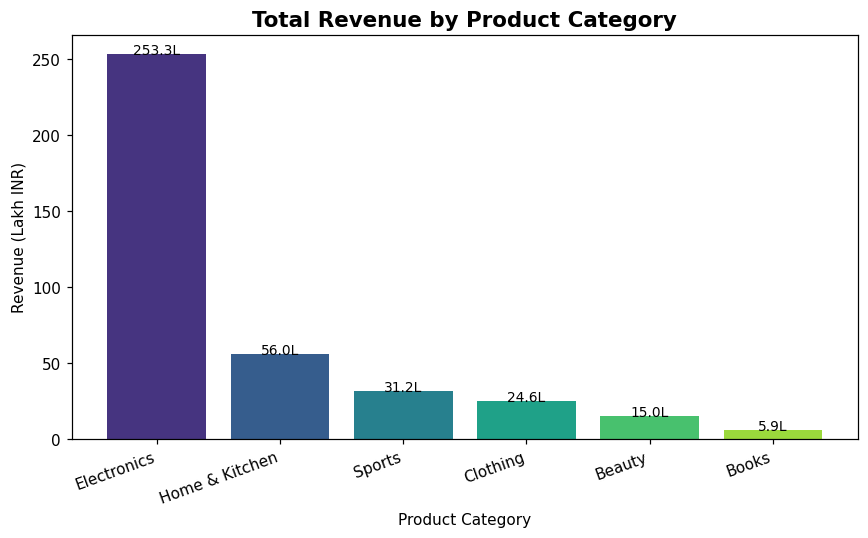

In [12]:
os.makedirs("visualizations", exist_ok=True)

# ---------- Chart 1: Bar chart — Revenue by Category ----------
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(revenue_by_category)))
ax.bar(revenue_by_category.index, revenue_by_category.values / 1e5, color=colors)
ax.set_title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue (Lakh INR)")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(revenue_by_category.values / 1e5):
    ax.text(i, v + 0.05, f"{v:.1f}L", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("visualizations/01_revenue_by_category_bar.png", bbox_inches="tight")
plt.show()

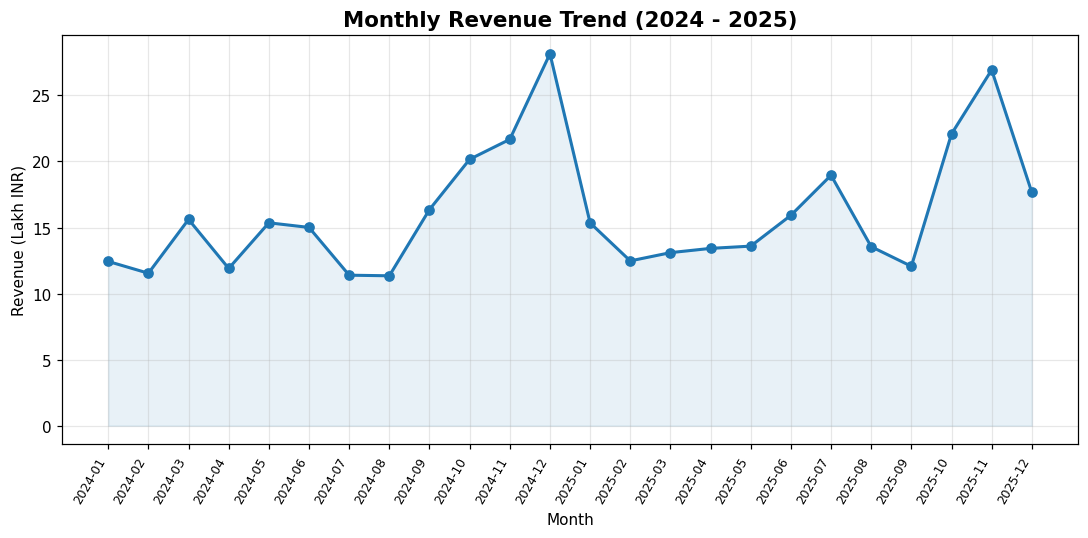

In [13]:
# ---------- Chart 2: Line chart — Monthly Revenue Trend ----------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values / 1e5, marker="o", color="#1f77b4", linewidth=2)
ax.fill_between(monthly_revenue.index, monthly_revenue.values / 1e5, alpha=0.1, color="#1f77b4")
ax.set_title("Monthly Revenue Trend (2024 - 2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (Lakh INR)")
ax.grid(alpha=0.3)
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("visualizations/02_monthly_revenue_trend_line.png", bbox_inches="tight")
plt.show()

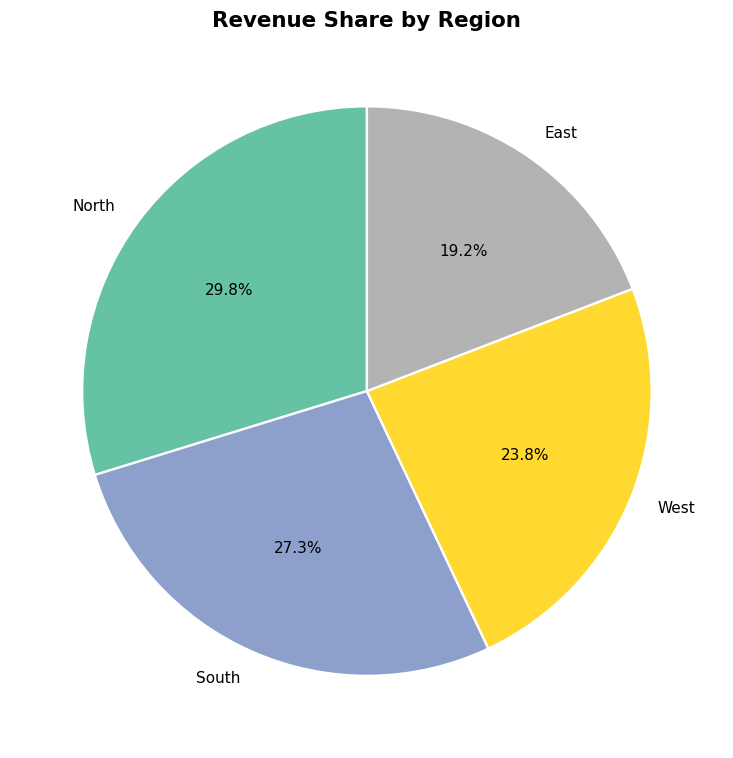

In [14]:
# ---------- Chart 3: Pie chart — Revenue Share by Region ----------
fig, ax = plt.subplots(figsize=(7, 7))
colors_pie = plt.cm.Set2(np.linspace(0, 1, len(revenue_by_region)))
ax.pie(revenue_by_region.values, labels=revenue_by_region.index, autopct="%1.1f%%",
       startangle=90, colors=colors_pie, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Revenue Share by Region", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/03_revenue_share_by_region_pie.png", bbox_inches="tight")
plt.show()

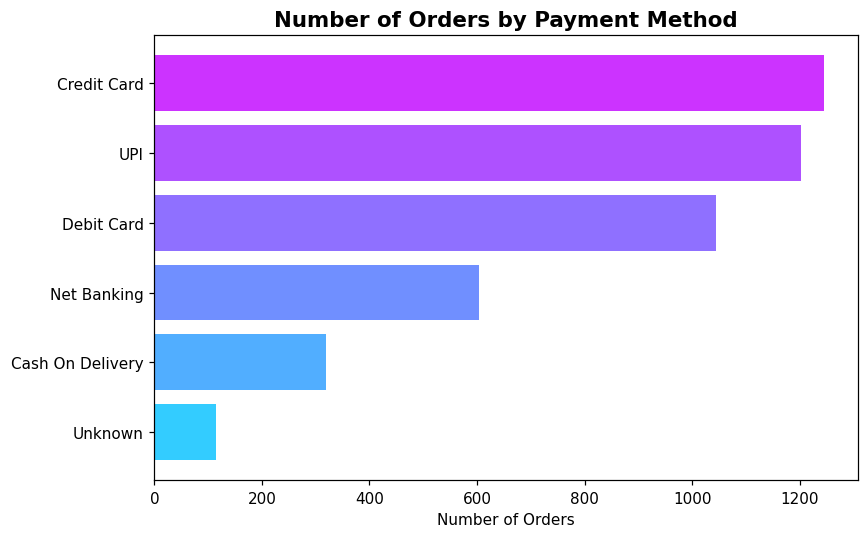


✅ All 4 charts saved to the visualizations/ folder


In [15]:
# ---------- Chart 4: Horizontal bar chart — Orders by Payment Method ----------
fig, ax = plt.subplots(figsize=(8, 5))
colors4 = plt.cm.cool(np.linspace(0.2, 0.8, len(orders_by_payment)))
ax.barh(orders_by_payment.index[::-1], orders_by_payment.values[::-1], color=colors4)
ax.set_title("Number of Orders by Payment Method", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Orders")
plt.tight_layout()
plt.savefig("visualizations/04_orders_by_payment_method_bar.png", bbox_inches="tight")
plt.show()

print("\n✅ All 4 charts saved to the visualizations/ folder")

## 7️⃣ Save the Cleaned Dataset

We save the cleaned, analysis-ready dataset alongside the raw one, so anyone
reviewing the project can see exactly what changed.

In [16]:
df.to_csv("data/ecommerce_sales_cleaned.csv", index=False)
print("Saved cleaned dataset to data/ecommerce_sales_cleaned.csv")
print("Final shape:", df.shape)

Saved cleaned dataset to data/ecommerce_sales_cleaned.csv
Final shape: (4533, 13)


## 8️⃣ Written Insights

**1. Electronics dominates revenue, far out of proportion to its order count.**
Electronics makes up roughly **22% of orders** but about **65–66% of total
revenue** — a direct result of high unit prices (₹1,500–₹45,000 per item). A
business takeaway: stock-outs or shipping delays in Electronics would hurt
revenue disproportionately more than in any other category, so it deserves the
most careful inventory planning.

**2. There is a clear, repeatable festive-season spike.**
Revenue rises sharply every **October–December**, averaging roughly **60%
higher** than the rest of the year, peaking in **December 2024**. This lines up
with festive/holiday shopping behavior and suggests marketing budgets and stock
levels should be front-loaded into Q4 rather than spread evenly across the year.

**3. Revenue is fairly evenly spread across regions, with North leading.**
North contributes about **30%** of revenue, South **27%**, West **24%**, and
East **19%**. No single region is overwhelmingly dominant, which is healthy —
it means the business isn't overexposed to any one market — but **East
under-performs** the other three and could be a target for regional promotions.

**4. Digital payments dominate, but a meaningful "Unknown" segment exists.**
Credit Card and UPI together account for the largest share of orders, while
Cash on Delivery trails behind. The presence of an "Unknown" payment-method
bucket (from missing data) is itself useful — it points to a checkout-flow
or logging gap worth fixing on the live platform, not just a data-cleaning
artifact.

**5. New and returning customers spend almost identically per order.**
Average order value is nearly the same for new vs. returning customers,
meaning the difference between the two segments is about *order frequency*,
not *order size*. A loyalty program aimed at increasing how *often* returning
customers buy — rather than how much they spend per visit — is likely to move
revenue more than a basket-size incentive.

> 📌 **Note:** Exact figures above are computed live in Section 5 each time this
> notebook runs, so update this section's specific numbers if you change the
> dataset or re-run with new data.

## 9️⃣ Conclusion

This project walked through a complete, real-world-style data analysis pipeline:

- **Loaded** 4,600+ raw order records with realistic data-quality problems
- **Cleaned** the data (standardized text, removed duplicates/invalid rows, filled
  missing values) and **validated** every cleaning step with explicit tests
- **Analyzed** revenue, order volume, returns, and customer behavior across four
  different dimensions (category, time, region, payment method)
- **Visualized** the findings with four chart types (bar, line, pie, horizontal bar)
- **Translated the numbers into five concrete, actionable business insights**

This mirrors the actual workflow a junior data analyst would follow on a real
e-commerce sales dataset — and every step above generalizes directly to any
other dataset shape (school grades, weather records, expense logs, etc.).